In [11]:
pip install rasterio

  Using cached rasterio-1.5.0-cp313-cp313-win_amd64.whl.metadata (8.9 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
Using cached rasterio-1.5.0-cp313-cp313-win_amd64.whl (30.1 MB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)

   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   -------------------------- ------------- 2/3 [rasterio]
   ---------------------------------------- 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import rasterio

with rasterio.open(r"C:\Users\Bhumi\OneDrive\Desktop\pathowatch\Browser_images\2026-01-11-00_00_2026-01-11-23_59_Sentinel-2_L2A_B04_(Raw).tiff") as src:
    band = src.read(1)

print(band.shape)



RasterioIOError: C:\Users\Bhumi\OneDrive\Desktop\pathowatch\Browser_images\2026-01-11-00_00_2026-01-11-23_59_Sentinel-2_L2A_B04_(Raw).tiff: No such file or directory

In [ ]:
import numpy as np

In [14]:
import os
print(os.getcwd())
print(os.listdir())
print(os.listdir("Browser_images"))



c:\Users\Bhumi\OneDrive\Desktop\pathowatch
['Browser_images', 'Browser_images.zip', 'pathowatch.ipynb']
['B02.tiff', 'B03.tiff', 'B04.tiff', 'B08.tiff']


In [18]:
import rasterio
import numpy as np
import os

folder = r"C:\Users\Bhumi\OneDrive\Desktop\pathowatch\Browser_images"

b2 = rasterio.open(os.path.join(folder, "B02.tiff")).read(1)
b3 = rasterio.open(os.path.join(folder, "B03.tiff")).read(1)
b4 = rasterio.open(os.path.join(folder, "B04.tiff")).read(1)
b8 = rasterio.open(os.path.join(folder, "B08.tiff")).read(1)

print(b2.shape)


(539, 1250)


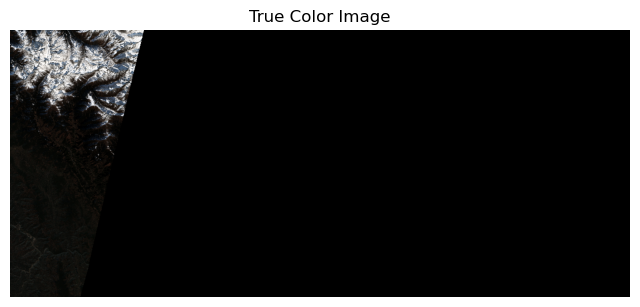

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Stack bands together to form an RGB image
rgb = np.dstack((b4, b3, b2))

# Display image
plt.figure(figsize=(8,6))
plt.imshow(rgb / np.max(rgb))
plt.title("True Color Image")
plt.axis("off")
plt.show()


In [20]:
import numpy as np

# Create mask where valid data exists
mask = (b4 > 0)

# Find rows and columns that contain any valid pixel
valid_rows = np.any(mask, axis=1)
valid_cols = np.any(mask, axis=0)

# Crop all bands using those rows and columns
b2_crop = b2[valid_rows][:, valid_cols]
b3_crop = b3[valid_rows][:, valid_cols]
b4_crop = b4[valid_rows][:, valid_cols]
b8_crop = b8[valid_rows][:, valid_cols]


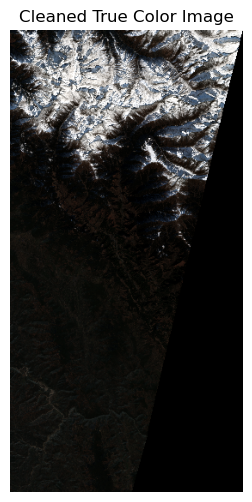

In [21]:
rgb_crop = np.dstack((b4_crop, b3_crop, b2_crop))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(rgb_crop / np.max(rgb_crop))
plt.title("Cleaned True Color Image")
plt.axis("off")
plt.show()


In [22]:
#vegetation index
# Convert to float to avoid integer division
b4_crop = b4_crop.astype(float)
b8_crop = b8_crop.astype(float)

# NDVI formula
ndvi = (b8_crop - b4_crop) / (b8_crop + b4_crop + 1e-10)


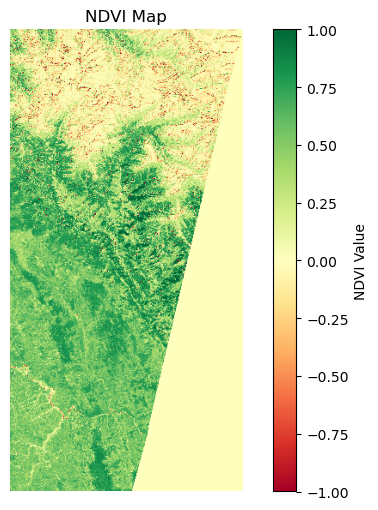

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label="NDVI Value")
plt.title("NDVI Map")
plt.axis("off")
plt.show()


In [25]:
import numpy as np

# Stack bands (each pixel becomes [B2, B3, B4, B8])
data = np.dstack((b2_crop, b3_crop, b4_crop, b8_crop))

print(data.shape)

# Get dimensions
h, w, d = data.shape

# Reshape for ML (pixels, features)
reshaped_data = data.reshape(-1, d)


(539, 271, 4)


In [ ]:

from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(reshaped_data)


In [10]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -----------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.02, random_state=42)

model.fit(pca_data)

anomaly_scores = model.decision_function(pca_data)


ModuleNotFoundError: No module named 'sklearn'

In [28]:
risk_map = anomaly_scores.reshape(h, w)


In [5]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
#Green → Normal
#Yellow → Slight anomaly
#Red → High anomaly
#Red areas = potential environmental stress / abnormal pattern.
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.imshow(risk_map, cmap='RdYlGn_r')
plt.colorbar(label="Risk Score")
plt.title("PathoWatch AI-Based Risk Map")
plt.axis("off")
plt.show()


threshold = np.percentile(anomaly_scores, 5)  # Top 5% as high risk
high_risk_pixels = anomaly_scores < threshold
risk_percentage = np.mean(high_risk_pixels) * 100
print(f"High Risk Area: {risk_percentage:.2f}% of the field")

plt.figure(figsize=(7,5))
plt.hist(anomaly_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label='High Risk Threshold')
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

NameError: name 'risk_map' is not defined

<Figure size 800x600 with 0 Axes>

In [5]:
def run_pathowatch_pipeline(lat,lon) :
    data = np.dstack((b2_crop, b3_crop, b4_crop, b8_crop))
    h, w, d = data.shape
    reshaped_data = data.reshape(-1, d) 

    pca = PCA(n_components=3)
    pca_data = pca.fit_transform(reshaped_data)

    model = IsolationForest(contamination=0.02, random_state=42)
    model.fit(pca_data)

    anomaly_scores = model.decision_function(pca_data)
    risk_map = anomaly_scores.reshape(h, w)

    high_risk = anomaly_scores < np.percentile(anomaly_scores, 5)
    risk_percentage = (np.sum(high_risk) / len(anomaly_scores)) * 100

    return risk_map, round(risk_percentage, 2)